# NILM Data Exploration : UK-DALE

**Objective:** Understand the raw data before building the preprocessing pipeline.

This notebook visualizes:
1. Raw aggregate power signal
2. Each target appliance's power signature
3. Duty cycles and ON/OFF statistics
4. Sampling rate consistency and gaps
5. DWT decomposition of a real event (kettle turn-on)
6. Cross-appliance overlap (when multiple appliances run together)


## 0. Setup : Imports and Path Configuration

In [2]:
import sys
from pathlib import Path

# Add src/ to the path so we can import our own modules
sys.path.append(str(Path.cwd().parent / "src"))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from config import DATASETS, APPLIANCES, APPLIANCE_NAMES, WINDOW_SIZE
from preprocessing import (
    load_ukdale_house,
    preprocess_house,
    UKDALE_METER_MAP,
)
from dwt import decompose_window, resample_subbands, dwt_transform

# Consistent plot style across the whole notebook
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 10

COLORS = {
    "aggregate": "#3366CC",
    "kettle": "#D94040",
    "fridge": "#2E9E5A",
    "washing_machine": "#E8922A",
    "dishwasher": "#7B4FBF",
    "microwave": "#CC3399",
}

print("Setup complete.")

Setup complete.


## 1. Load Raw Data :UK-DALE House 1

This calls our `preprocessing.py` module directly. If the meter mapping
is wrong, we will see it immediately in the plots below.

In [5]:
HOUSE = 1

raw_df = load_ukdale_house(house=HOUSE)
print(f"\nShape: {raw_df.shape}")
print(f"Date range: {raw_df.index[0]} to {raw_df.index[-1]}")
raw_df.head()

Loading UK-DALE House 1...
  [OK] aggregate (meter1): 10239433 points, 2012-11-09 22:28:15+00:00 to 2015-01-05 06:15:46+00:00
  [OK] kettle (meter10): 8942091 points, 2012-11-09 22:28:18+00:00 to 2015-01-05 06:16:04+00:00
  [OK] fridge (meter12): 8972363 points, 2012-12-14 22:21:32+00:00 to 2015-01-05 06:16:43+00:00
  [OK] washing_machine (meter5): 9194001 points, 2012-11-09 22:28:18+00:00 to 2015-01-05 06:25:18+00:00
  [OK] dishwasher (meter6): 9315898 points, 2012-11-09 22:28:18+00:00 to 2015-01-05 06:25:38+00:00
  [OK] microwave (meter13): 9018806 points, 2012-12-14 22:21:33+00:00 to 2015-01-05 06:17:02+00:00
  Resampling each series to 6s before joining...
    aggregate: 11323076 points after resample
    kettle: 11323078 points after resample
    fridge: 10819153 points after resample
    washing_machine: 11323171 points after resample
    dishwasher: 11323174 points after resample
    microwave: 10819156 points after resample

Shape: (11323175, 6)
Date range: 2012-11-09 22:28:12 

,aggregate,kettle,fridge,washing_machine,dishwasher,microwave
2012-11-09 22:28:12,599.0,NaN,NaN,NaN,NaN,NaN
2012-11-09 22:28:18,582.0,1.0,NaN,0.0,1.0,NaN
2012-11-09 22:28:24,600.0,1.0,NaN,0.0,1.0,NaN
2012-11-09 22:28:30,586.0,1.0,NaN,0.0,1.0,NaN
2012-11-09 22:28:36,596.0,1.0,NaN,0.0,1.0,NaN


## 2. Missing Data Overview

Before cleaning, let's see exactly how much data is missing per appliance.
Some appliances may not be monitored in every house ,this will show as 100% NaN.

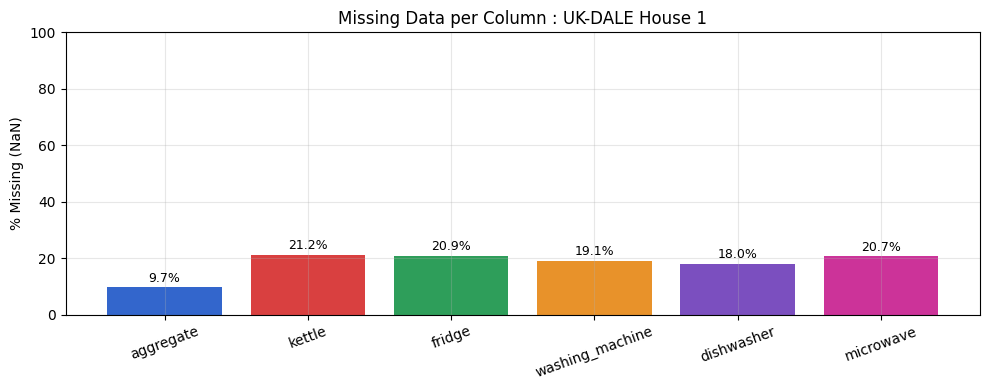

In [7]:
 missing_pct = raw_df.isna().mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(missing_pct.index, missing_pct.values,
              color=[COLORS.get(c, "#888") for c in missing_pct.index])
ax.set_ylabel("% Missing (NaN)")
ax.set_title(f"Missing Data per Column : UK-DALE House {HOUSE}")
ax.set_ylim(0, 100)
for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, f"{val:.1f}%",
            ha="center", fontsize=9)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3. Sampling Rate Consistency

UK-DALE is nominally sampled every 6 seconds, but real smart meters have
irregular gaps. Let's see the actual distribution of time gaps between
consecutive aggregate power measurements.

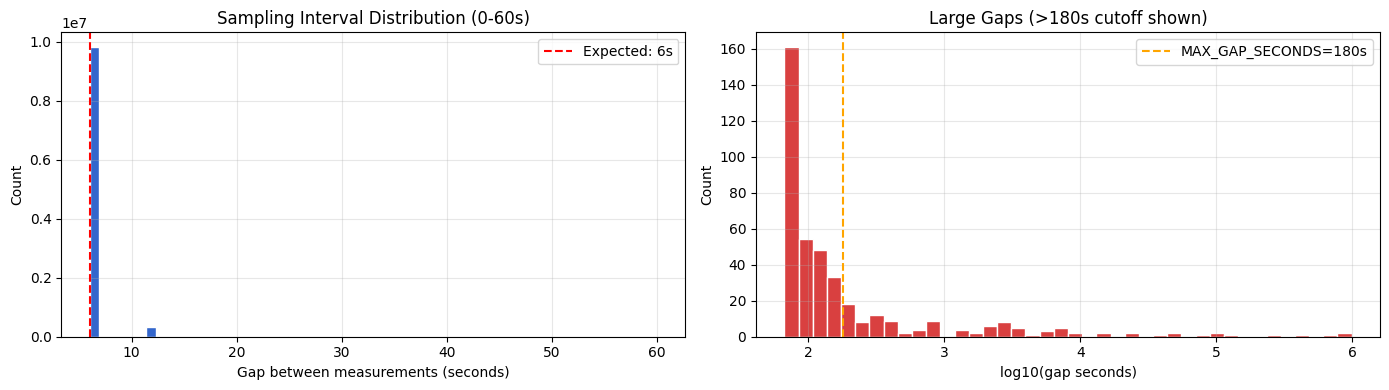

Median gap: 6.0s
% of gaps <= 6s:   96.2%
% of gaps <= 180s: 100.0%
% of gaps > 180s (will be dropped): 0.00%


In [9]:
agg = raw_df["aggregate"].dropna()
time_diffs = agg.index.to_series().diff().dt.total_seconds().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of gaps (zoomed to 0-60 seconds)
axes[0].hist(time_diffs[time_diffs <= 60], bins=60, color="#3366CC", edgecolor="white")
axes[0].set_xlabel("Gap between measurements (seconds)")
axes[0].set_ylabel("Count")
axes[0].set_title("Sampling Interval Distribution (0-60s)")
axes[0].axvline(6, color="red", linestyle="--", label="Expected: 6s")
axes[0].legend()

# How many gaps exceed our MAX_GAP_SECONDS threshold?
from config import MAX_GAP_SECONDS
large_gaps = time_diffs[time_diffs > MAX_GAP_SECONDS]
axes[1].hist(np.log10(time_diffs[time_diffs > 60] + 1), bins=40, color="#D94040", edgecolor="white")
axes[1].set_xlabel("log10(gap seconds)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Large Gaps (>{MAX_GAP_SECONDS}s cutoff shown)")
axes[1].axvline(np.log10(MAX_GAP_SECONDS), color="orange", linestyle="--",
                label=f"MAX_GAP_SECONDS={MAX_GAP_SECONDS}s")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Median gap: {time_diffs.median():.1f}s")
print(f"% of gaps <= 6s:   {(time_diffs <= 6).mean()*100:.1f}%")
print(f"% of gaps <= {MAX_GAP_SECONDS}s: {(time_diffs <= MAX_GAP_SECONDS).mean()*100:.1f}%")
print(f"% of gaps > {MAX_GAP_SECONDS}s (will be dropped): {(time_diffs > MAX_GAP_SECONDS).mean()*100:.2f}%")

## 4. Run the Full Preprocessing Pipeline

This applies resampling, gap-filling, outlier clipping, and state labeling ,
the exact pipeline your model will use during training.

In [10]:
clean_df = preprocess_house(raw_df)
clean_df.head()


Preprocessing pipeline:
  Input shape: (11323175, 6)
  After resampling (6s): (11323175, 6)
  After gap-filling: 4446970 NaN remaining
  Outliers clipped per appliance config
  State labels computed: ['kettle_state', 'fridge_state', 'washing_machine_state', 'dishwasher_state', 'microwave_state']
  Dropped 1152328 rows with unfillable gaps
  Final shape: (10170847, 11)


,aggregate,kettle,fridge,washing_machine,dishwasher,microwave,kettle_state,fridge_state,washing_machine_state,dishwasher_state,microwave_state
2012-12-14 22:21:30,993.0,1.0,85.0,0.0,1.0,1.0,0,1,0,0,0
2012-12-14 22:21:36,1003.0,1.0,85.0,0.0,1.0,1.0,0,1,0,0,0
2012-12-14 22:21:42,1008.0,1.0,84.0,0.0,1.0,1.0,0,1,0,0,0
2012-12-14 22:21:48,997.0,1.0,85.0,0.0,1.0,1.0,0,1,0,0,0
2012-12-14 22:21:54,1011.0,1.0,85.0,0.0,1.0,1.0,0,1,0,0,0


## 5. Aggregate Power : Full Time Series Overview

A bird's-eye view of the whole recording period. Look for seasonal
patterns, missing chunks, or unrealistic spikes.

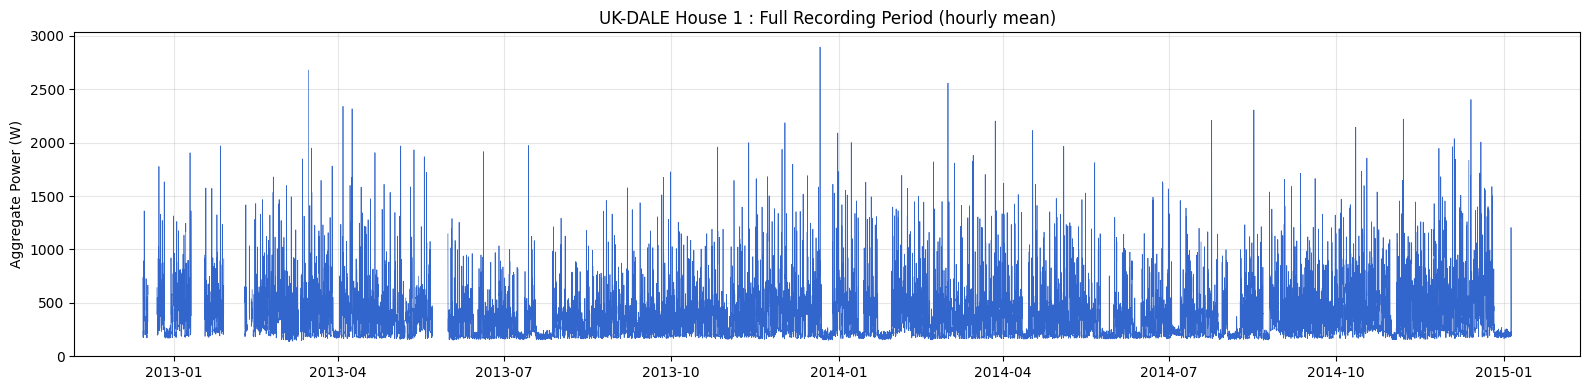

Total duration: 751 days
Total clean measurements: 10,170,847


In [12]:
fig, ax = plt.subplots(figsize=(16, 4))

# Downsample for plotting speed — 1 point per hour is enough to see trends
agg_hourly = clean_df["aggregate"].resample("1h").mean()
ax.plot(agg_hourly.index, agg_hourly.values, color=COLORS["aggregate"], linewidth=0.5)
ax.set_ylabel("Aggregate Power (W)")
ax.set_title(f"UK-DALE House {HOUSE} : Full Recording Period (hourly mean)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.show()

print(f"Total duration: {(clean_df.index[-1] - clean_df.index[0]).days} days")
print(f"Total clean measurements: {len(clean_df):,}")

## 6. Zoom In : One Day of Activity

Pick a random day and look at the aggregate signal alongside every
individual appliance overlaid. This is the most important plot for
verifying that our meter mapping is correct , appliance spikes should
visibly correspond to bumps in the aggregate signal.

Using fallback day: 2012-12-15


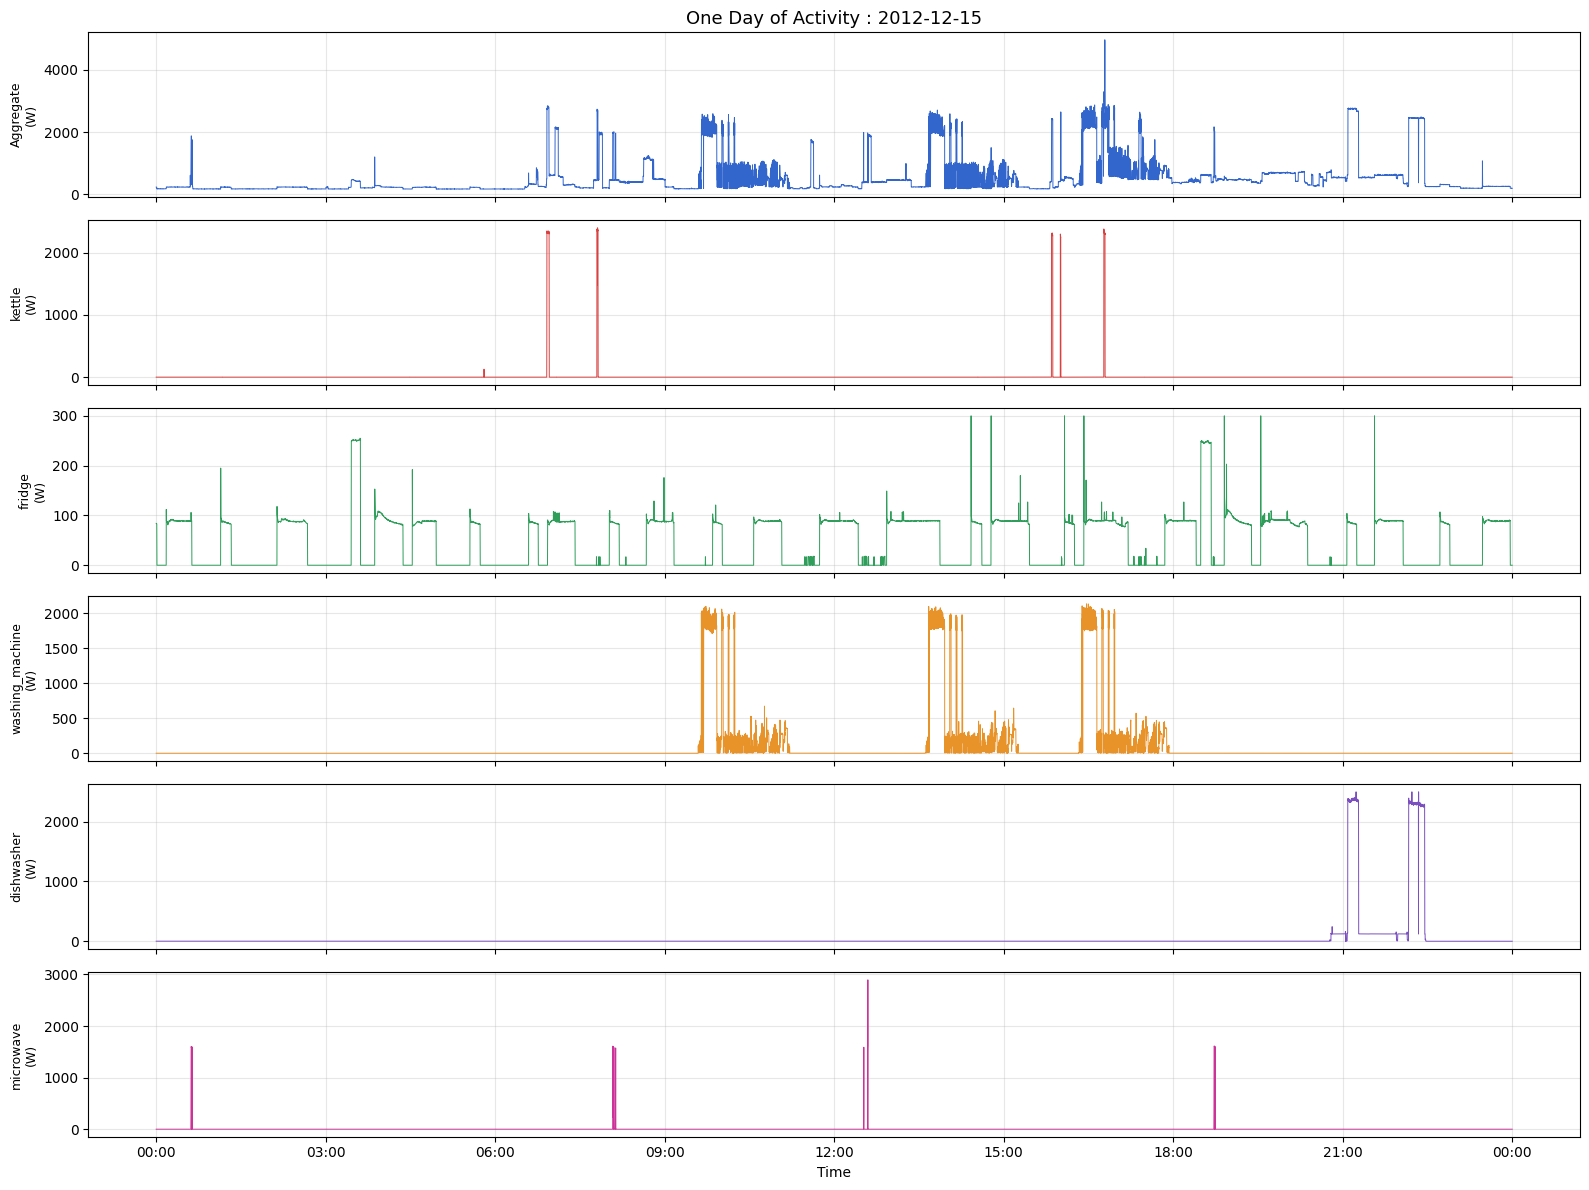

In [14]:
# Pick a day with high activity (look for a day where multiple appliances have nonzero max)
day_data = clean_df.loc["2013-01-15"]  # adjust date if this day has no data

if len(day_data) == 0:
    # Fallback: just take the first full day available
    first_day = clean_df.index[1000].date()
    day_data = clean_df.loc[str(first_day)]
    print(f"Using fallback day: {first_day}")

fig, axes = plt.subplots(len(APPLIANCE_NAMES) + 1, 1, figsize=(16, 12), sharex=True)

axes[0].plot(day_data.index, day_data["aggregate"], color=COLORS["aggregate"], linewidth=0.7)
axes[0].set_ylabel("Aggregate\n(W)", fontsize=9)
axes[0].set_title(f"One Day of Activity : {day_data.index[0].date()}", fontsize=13)

for i, appliance in enumerate(APPLIANCE_NAMES):
    ax = axes[i + 1]
    ax.plot(day_data.index, day_data[appliance], color=COLORS[appliance], linewidth=0.7)
    ax.set_ylabel(f"{appliance}\n(W)", fontsize=9)

axes[-1].set_xlabel("Time")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

## 7. Appliance Power Distributions

Histograms of power values (log scale) reveal the ON/OFF bimodal nature
of appliance behavior , a large peak near 0W (OFF) and a smaller cluster
at the operating power level (ON).

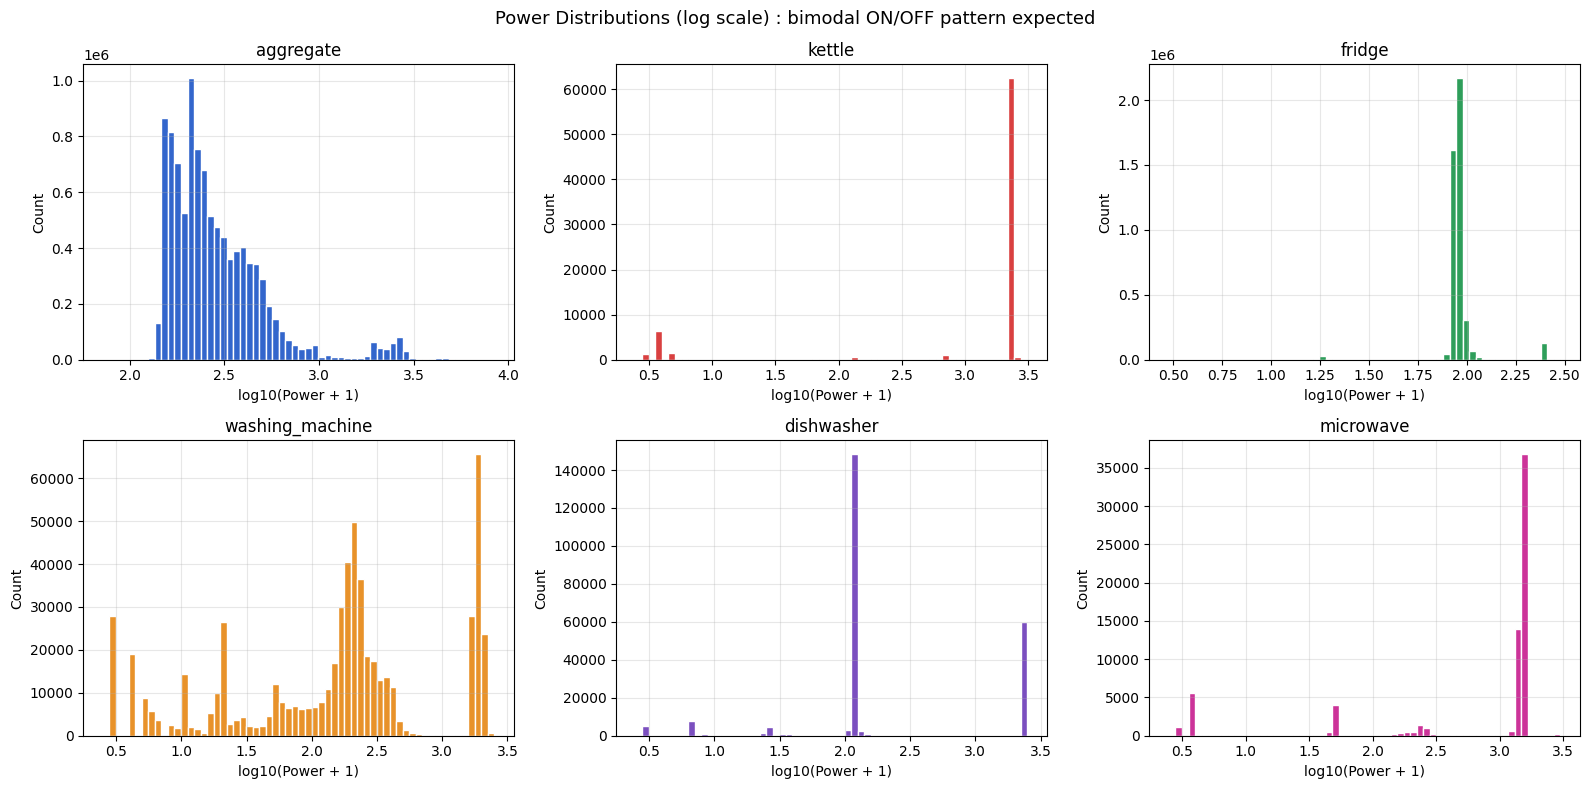

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

columns_to_plot = ["aggregate"] + APPLIANCE_NAMES
for i, col in enumerate(columns_to_plot):
    values = clean_df[col]
    values_nonzero = values[values > 1]  # avoid log(0)
    axes[i].hist(np.log10(values_nonzero + 1), bins=60,
                 color=COLORS.get(col, "#888"), edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("log10(Power + 1)")
    axes[i].set_ylabel("Count")

plt.suptitle("Power Distributions (log scale) : bimodal ON/OFF pattern expected", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Duty Cycle Summary Table

Quantifies what we saw visually: % of time each appliance is ON,
average power when ON, and max power observed.

In [17]:
summary_rows = []
for appliance in APPLIANCE_NAMES:
    power = clean_df[appliance]
    state_col = f"{appliance}_state"
    threshold = APPLIANCES[appliance]["power_threshold"]

    duty_cycle = clean_df[state_col].mean() * 100 if state_col in clean_df else np.nan
    mean_when_on = power[power > threshold].mean() if (power > threshold).any() else 0

    summary_rows.append({
        "appliance": appliance,
        "threshold_W": threshold,
        "duty_cycle_%": round(duty_cycle, 2),
        "mean_power_when_ON_W": round(mean_when_on, 1),
        "max_power_W": round(power.max(), 1),
        "n_events": int((clean_df[state_col].diff() == 1).sum()) if state_col in clean_df else np.nan,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,appliance,threshold_W,duty_cycle_%,mean_power_when_ON_W,max_power_W,n_events
0,kettle,2000,0.62,2342.300049,3100.0,3394
1,fridge,50,42.97,94.099998,300.0,18685
2,washing_machine,20,4.60,619.000000,2500.0,59192
3,dishwasher,10,2.20,709.299988,2500.0,1789
4,microwave,200,0.55,1442.300049,3000.0,6199


## 9. DWT Decomposition on a Real Event

Find an actual kettle turn-on event in the data and show how DWT
decomposes it into sub-bands  this validates that HP1 (fast transients)
correctly captures the sharp switching moment.

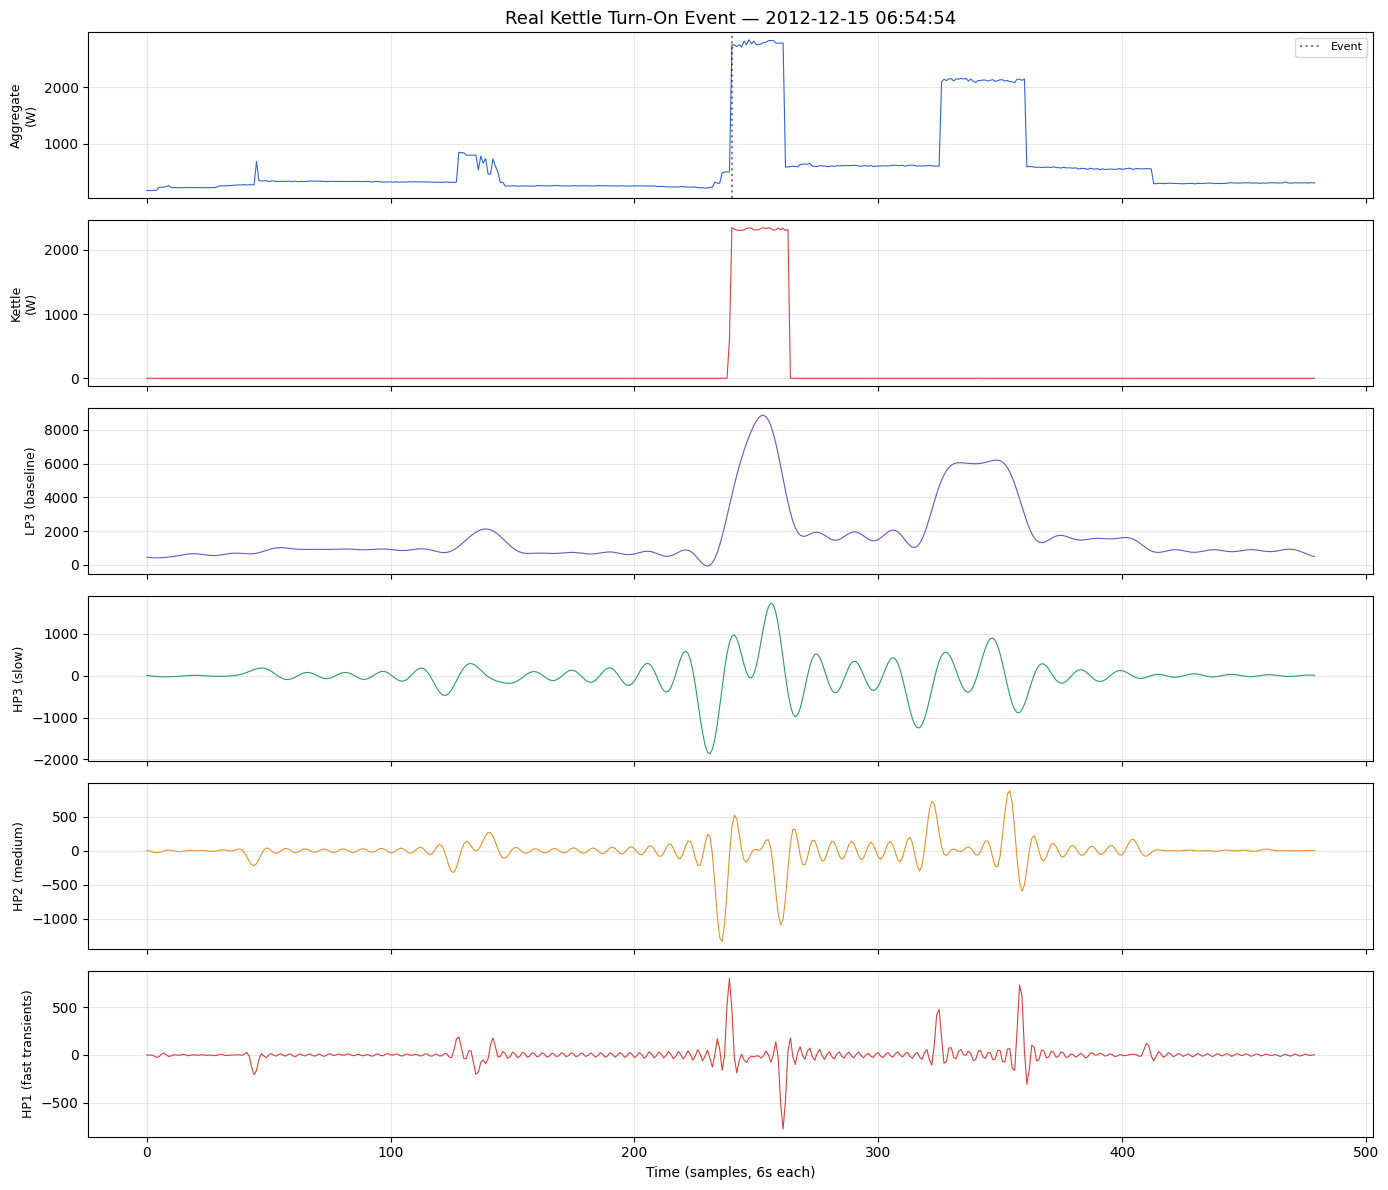

Event found at: 2012-12-15 06:54:54
Aggregate power jump: 495W -> 2725W


In [19]:
# Find a window containing a kettle turn-on event
kettle_state = clean_df["kettle_state"]
turn_on_indices = clean_df.index[(kettle_state.diff() == 1)]

if len(turn_on_indices) > 0:
    event_time = turn_on_indices[0]
    event_pos = clean_df.index.get_loc(event_time)

    # Extract a window centered on the event
    half_window = WINDOW_SIZE // 2
    start = max(0, event_pos - half_window)
    end = start + WINDOW_SIZE

    window_agg = clean_df["aggregate"].iloc[start:end].values
    window_kettle = clean_df["kettle"].iloc[start:end].values

    if len(window_agg) == WINDOW_SIZE:
        # Decompose the aggregate signal at this event
        subbands = decompose_window(window_agg)
        features = resample_subbands(subbands, WINDOW_SIZE)

        names = ["LP3 (baseline)", "HP3 (slow)", "HP2 (medium)", "HP1 (fast transients)"]
        colors_dwt = ["#7B4FBF", "#2E9E5A", "#E8922A", "#D94040"]

        fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)

        axes[0].plot(window_agg, color=COLORS["aggregate"], linewidth=0.8)
        axes[0].set_ylabel("Aggregate\n(W)", fontsize=9)
        axes[0].set_title(f"Real Kettle Turn-On Event — {event_time}", fontsize=13)
        axes[0].axvline(half_window, color="black", linestyle=":", alpha=0.5, label="Event")
        axes[0].legend(fontsize=8)

        axes[1].plot(window_kettle, color=COLORS["kettle"], linewidth=0.8)
        axes[1].set_ylabel("Kettle\n(W)", fontsize=9)

        for i, (name, color) in enumerate(zip(names, colors_dwt)):
            axes[i + 2].plot(features[i], color=color, linewidth=0.8)
            axes[i + 2].set_ylabel(name, fontsize=9)

        axes[-1].set_xlabel("Time (samples, 6s each)")
        plt.tight_layout()
        plt.show()

        print(f"Event found at: {event_time}")
        print(f"Aggregate power jump: {window_agg[half_window-2]:.0f}W -> {window_agg[half_window+2]:.0f}W")
    else:
        print("Window at edge of data, try a different event index.")
else:
    print("No kettle turn-on events found — check kettle meter mapping!")

## 10. Appliance Overlap Analysis

How often do multiple appliances run simultaneously? This quantifies
the difficulty of the disaggregation problem , more overlap means
harder to distinguish individual contributions from the aggregate.

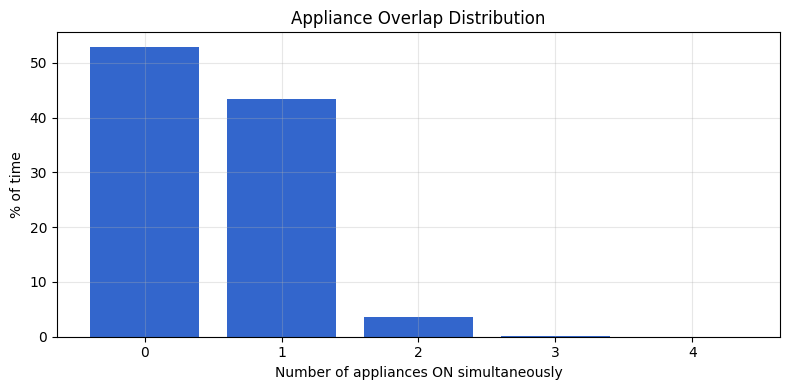

% of time with 0 appliances ON: 52.9%
% of time with 2+ appliances ON simultaneously: 3.7%


In [20]:
state_cols = [f"{a}_state" for a in APPLIANCE_NAMES if f"{a}_state" in clean_df.columns]
n_simultaneous = clean_df[state_cols].sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
counts = n_simultaneous.value_counts().sort_index()
ax.bar(counts.index, counts.values / len(clean_df) * 100, color="#3366CC")
ax.set_xlabel("Number of appliances ON simultaneously")
ax.set_ylabel("% of time")
ax.set_title("Appliance Overlap Distribution")
plt.tight_layout()
plt.show()

print(f"% of time with 0 appliances ON: {(n_simultaneous == 0).mean()*100:.1f}%")
print(f"% of time with 2+ appliances ON simultaneously: {(n_simultaneous >= 2).mean()*100:.1f}%")

## 11. Sanity Check :Sum of Appliances vs Aggregate

Since we only monitor 5 appliances out of many in the house, the sum
of our appliances will always be LESS than the aggregate (the
difference is unmonitored load ,lights, electronics, etc). This is
expected and normal, but the sum should never EXCEED the aggregate.

% of time appliance_sum > aggregate (should be near 0%): 0.50%
Average coverage (monitored / total): 18.8%


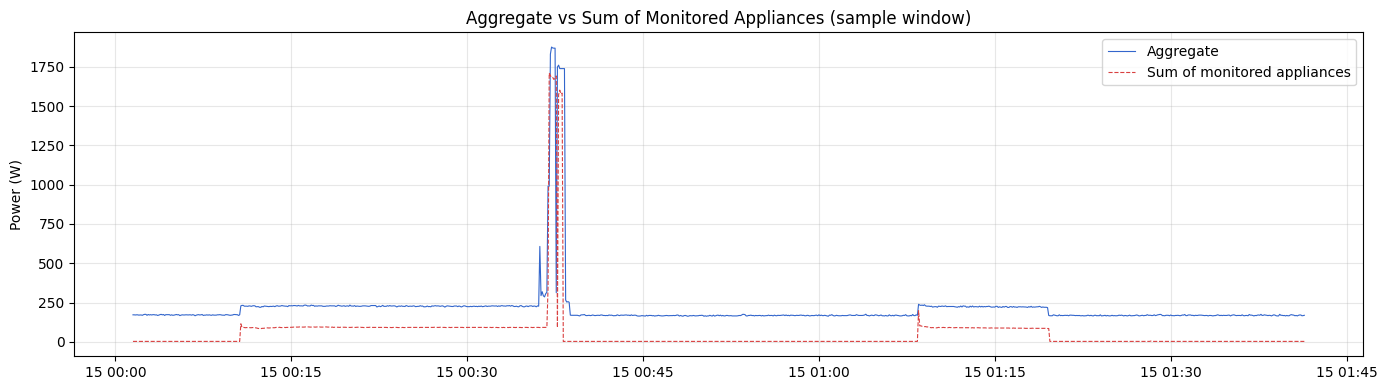

In [21]:
appliance_sum = clean_df[APPLIANCE_NAMES].sum(axis=1)
aggregate = clean_df["aggregate"]

violation_pct = (appliance_sum > aggregate).mean() * 100
coverage_pct = (appliance_sum / aggregate.replace(0, np.nan)).mean() * 100

print(f"% of time appliance_sum > aggregate (should be near 0%): {violation_pct:.2f}%")
print(f"Average coverage (monitored / total): {coverage_pct:.1f}%")

fig, ax = plt.subplots(figsize=(14, 4))
sample = clean_df.iloc[1000:2000]
ax.plot(sample.index, sample["aggregate"], label="Aggregate", color=COLORS["aggregate"], linewidth=0.8)
ax.plot(sample.index, sample[APPLIANCE_NAMES].sum(axis=1), label="Sum of monitored appliances",
        color="#D94040", linewidth=0.8, linestyle="--")
ax.set_ylabel("Power (W)")
ax.set_title("Aggregate vs Sum of Monitored Appliances (sample window)")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Summary :What This Notebook Confirmed

Fill in your observations after running all cells:

- [ ] Meter mapping produces physically plausible signals (spikes align with events)
- [ ] Sampling rate is consistent at ~6s with acceptable gap distribution
- [ ] Duty cycles match expected appliance behavior
- [ ] DWT sub-bands correctly isolate transient events (HP1) vs baseline (LP3)
- [ ] Appliance sum never exceeds aggregate (physical consistency check passed)
- [ ] Overlap analysis shows realistic multi-appliance usage patterns

**Next step:** repeat this notebook for House 2 (test set) and for REDD to
verify the meter mappings before running any training.